<a href="https://colab.research.google.com/github/celalthedon/cnn-experiments/blob/main/resnet_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
from dataclasses import dataclass

In [11]:
@dataclass
class DataCFG:
    data_path: str = "./data"
    img_size: int = 224
    batch_size: int = 32
    num_workers: int = 2


@dataclass
class TrainCFG:
    epochs: int = 10
    lr: float = 1e-3
    weight_decay: float = 1e-4
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


@dataclass
class ModelCFG:
    in_channels: int = 3
    num_classes: int = 10
    base_channels: int = 64

In [12]:
data_cfg = DataCFG()
train_cfg = TrainCFG()
model_cfg = ModelCFG()

In [14]:
train_tfms = transforms.Compose([
    transforms.Resize((data_cfg.img_size, data_cfg.img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

test_tfms = transforms.Compose([
    transforms.Resize((data_cfg.img_size, data_cfg.img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5]),
])

In [15]:
train_dataset = datasets.CIFAR10(
    root=data_cfg.data_path,
    train=True,
    download=True,
    transform=train_tfms
)

test_dataset = datasets.CIFAR10(
    root=data_cfg.data_path,
    train=False,
    download=True,
    transform=test_tfms
)

100%|██████████| 170M/170M [00:03<00:00, 47.7MB/s]


In [16]:
train_loader = DataLoader(
    train_dataset,
    batch_size=data_cfg.batch_size,
    shuffle=True,
    num_workers=data_cfg.num_workers
)

test_loader = DataLoader(
    test_dataset,
    batch_size=data_cfg.batch_size,
    shuffle=False,
    num_workers=data_cfg.num_workers
)


#Let's build our Model

##downsample

In [27]:
class DownsampleLayer(nn.Module):
  def __init__(self, in_channels: int, out_channels: int, stride: int):
    super().__init__()

    self.conv = nn.Conv2d(
        in_channels=in_channels,
        out_channels=out_channels,
        kernel_size=1,
        stride=stride,
        bias = False
    )

    self.bn = nn.BatchNorm2d(out_channels)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.conv(x)
    x = self.bn(x)

    return x

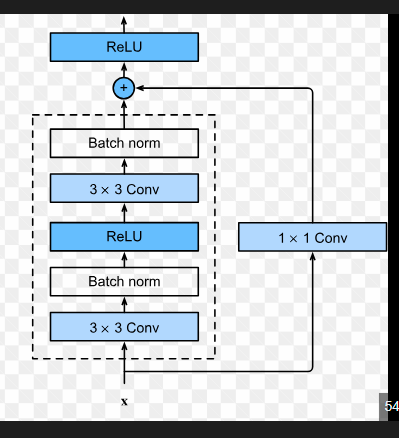

In [28]:
class BasicBlock(nn.Module):
  expansion = 1

  def __init__(
      self,
      in_channels: int,
      out_channels: int,
      stride: int = 1,
      downsample: nn.Module | None = None
  ):
    super().__init__()

    self.conv1 = nn.Conv2d(
        in_channels = in_channels,
        out_channels = out_channels,
        kernel_size=3,
        stride= stride,
        padding=1,
        bias=False
    )

    self.bn1 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace=True)

    self.conv2 = nn.Conv2d(
        in_channels = out_channels,
        out_channels = out_channels,
        kernel_size=3,
        stride=1,
        padding=1,
        bias=False
    )

    self.bn2 = nn.BatchNorm2d(out_channels)
    self.downsample = downsample

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    identity = x

    out = self.conv1(x)
    out = self.bn1(out)
    out = self.relu(out)

    out = self.conv2(out)
    out = self.bn2(out)

    if self.downsample is not None:
      identity = self.downsample(x)

    out = out + identity
    out = self.relu(out)

    return out

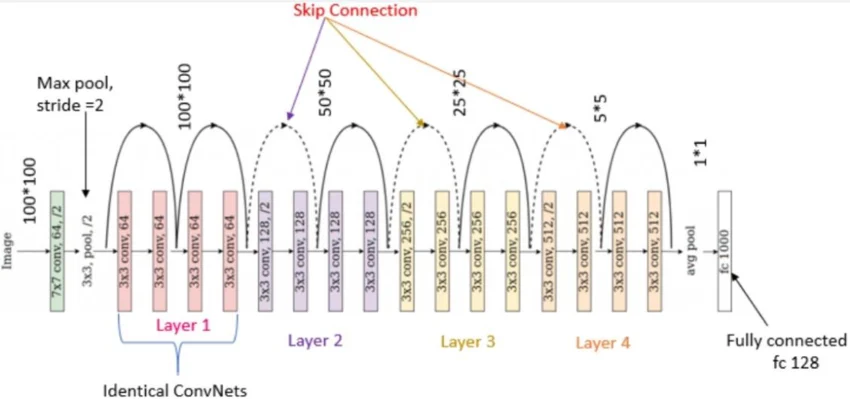

In [39]:
class ResNet18(nn.Module):
  def __init__(self, cfg: ModelCFG):
    super().__init__()

    self.cfg = cfg

    self.conv1 = nn.Conv2d(
        in_channels = cfg.in_channels,
        out_channels = cfg.base_channels,
        kernel_size = 7,
        stride = 2,
        padding = 3,
        bias = False
    )

    self.bn1 = nn.BatchNorm2d(cfg.base_channels)
    self.relu = nn.ReLU(inplace = True)
    self.maxpool = nn.MaxPool2d(kernel_size = 3, stride = 2, padding = 1)

    self.layer1_block1 = BasicBlock(64,64, stride = 1, downsample=None)
    self.layer1_block2 = BasicBlock(64,64, stride = 1, downsample=None)

    self.layer2_downsample = DownsampleLayer(64,128, stride = 2)
    self.layer2_block1 = BasicBlock(64,128, stride = 2, downsample=self.layer2_downsample)
    self.layer2_block2 = BasicBlock(128,128, stride = 1, downsample=None)

    self.layer3_downsample = DownsampleLayer(128,256, stride = 2)
    self.layer3_block1 = BasicBlock(128,256, stride = 2, downsample=self.layer3_downsample)
    self.layer3_block2 = BasicBlock(256,256, stride = 1, downsample=None)

    self.layer4_downsample = DownsampleLayer(256, 512, stride=2)
    self.layer4_block1 = BasicBlock(256, 512, stride=2, downsample=self.layer4_downsample)
    self.layer4_block2 = BasicBlock(512, 512, stride=1, downsample=None)

    self.avgpool = nn.AdaptiveAvgPool2d((1,1))
    self.fc = nn.Linear(512* BasicBlock.expansion, cfg.num_classes)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x = self.layer1_block1(x)
    x = self.layer1_block2(x)

    x = self.layer2_block1(x)
    x = self.layer2_block2(x)

    x = self.layer3_block1(x)
    x = self.layer3_block2(x)

    x = self.layer4_block1(x)
    x = self.layer4_block2(x)

    x = self.avgpool(x)
    x = torch.flatten(x, start_dim=1)
    x = self.fc(x)

    return x

In [40]:
cfg = ModelCFG(
    in_channels=3,
    num_classes=10,
    base_channels=64
)

model = ResNet18(cfg)

In [41]:
model

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1_block1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer1_block2): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64

Input           : [B, 3, 224, 224]

conv1           : [B, 64, 112, 112]
bn1             : [B, 64, 112, 112]
relu            : [B, 64, 112, 112]
maxpool         : [B, 64, 56, 56]

layer1_block1   : [B, 64, 56, 56]
layer1_block2   : [B, 64, 56, 56]

layer2_block1   : [B, 128, 28, 28]
layer2_block2   : [B, 128, 28, 28]

layer3_block1   : [B, 256, 14, 14]
layer3_block2   : [B, 256, 14, 14]

layer4_block1   : [B, 512, 7, 7]
layer4_block2   : [B, 512, 7, 7]

avgpool         : [B, 512, 1, 1]
flatten         : [B, 512]
fc              : [B, num_classes]

In [42]:
!pip install torchview

In [44]:
from torchview import draw_graph

model = ResNet18(cfg)

graph = draw_graph(
    model,
    input_size=(1, 3, 224, 224),
    expand_nested=True
)

graph.visual_graph.render("resnet18", format="png")

'resnet18.png'

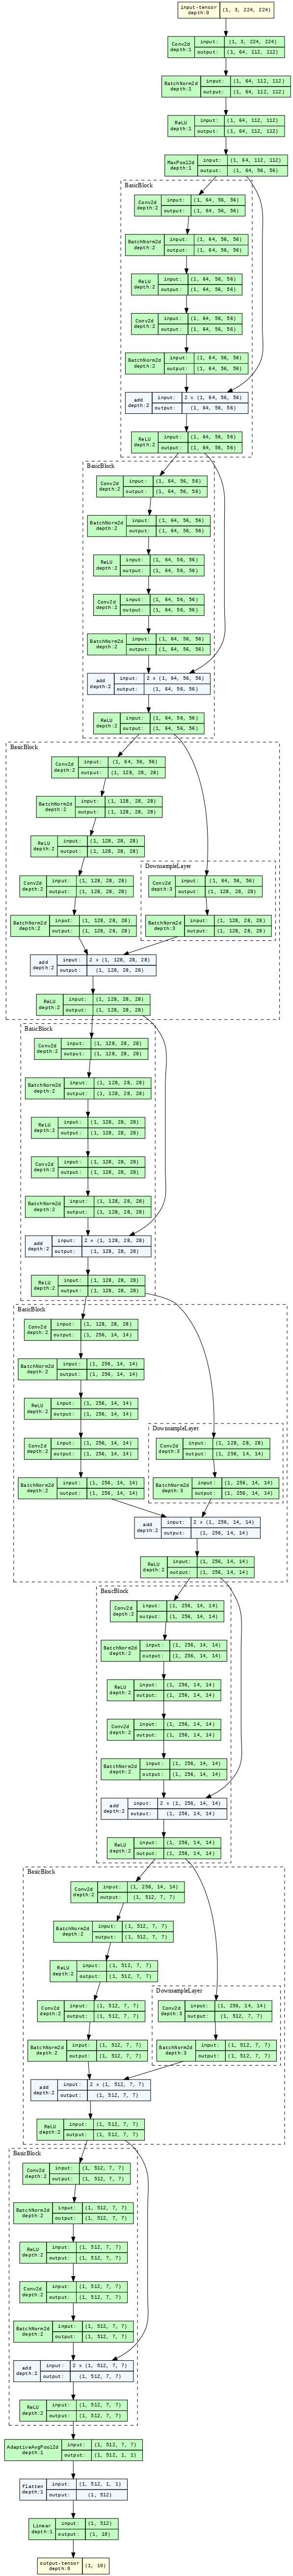

In [45]:
cfg = ModelCFG(in_channels=3, num_classes=10, base_channels=64)
model = ResNet18(cfg)
model.eval()

ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1_block1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer1_block2): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64

In [46]:
dummy_input = torch.randn(1, 3, 224, 224)

In [49]:
!pip install onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 81.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 56.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.1/164.1 kB 20.7 MB/s eta 0:00:00


In [50]:
torch.onnx.export(
    model,
    dummy_input,
    "resnet18_custom.onnx",
    export_params=True,
    opset_version=12,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "logits": {0: "batch_size"}
    }
)

/tmp/ipykernel_472/2506359674.py:1: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0418 18:01:35.304000 472 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0418 18:01:37.568000 472 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, align

[torch.onnx] Obtain model graph for `ResNet18([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet18([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 115, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 61 of general pattern rewrite rules.


ONNXProgram(
    model=
        <
            ir_version=10,
            opset_imports={'': 18},
            producer_name='pytorch',
            producer_version='2.10.0+cu128',
            domain=None,
            model_version=None,
        >
        graph(
            name=main_graph,
            inputs=(
                %"input"<FLOAT,[batch_size,3,224,224]>
            ),
            outputs=(
                %"logits"<FLOAT,[batch_size,10]>
            ),
            initializers=(
                %"fc.bias"<FLOAT,[10]>{TorchTensor<FLOAT,[10]>(Parameter containing: tensor([ 0.0016, -0.0011,  0.0059,  0.0282,  0.0126, -0.0030, -0.0145,  0.0334, -0.0162,  0.0153], requires_grad=True), name='fc.bias')},
                %"conv1.weight"<FLOAT,[64,3,7,7]>{Tensor(...)},
                %"layer1_block1.conv1.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1_block1.conv2.weight"<FLOAT,[64,64,3,3]>{Tensor(...)},
                %"layer1_block2.conv1.weight"<FLOAT,[64,64,3,

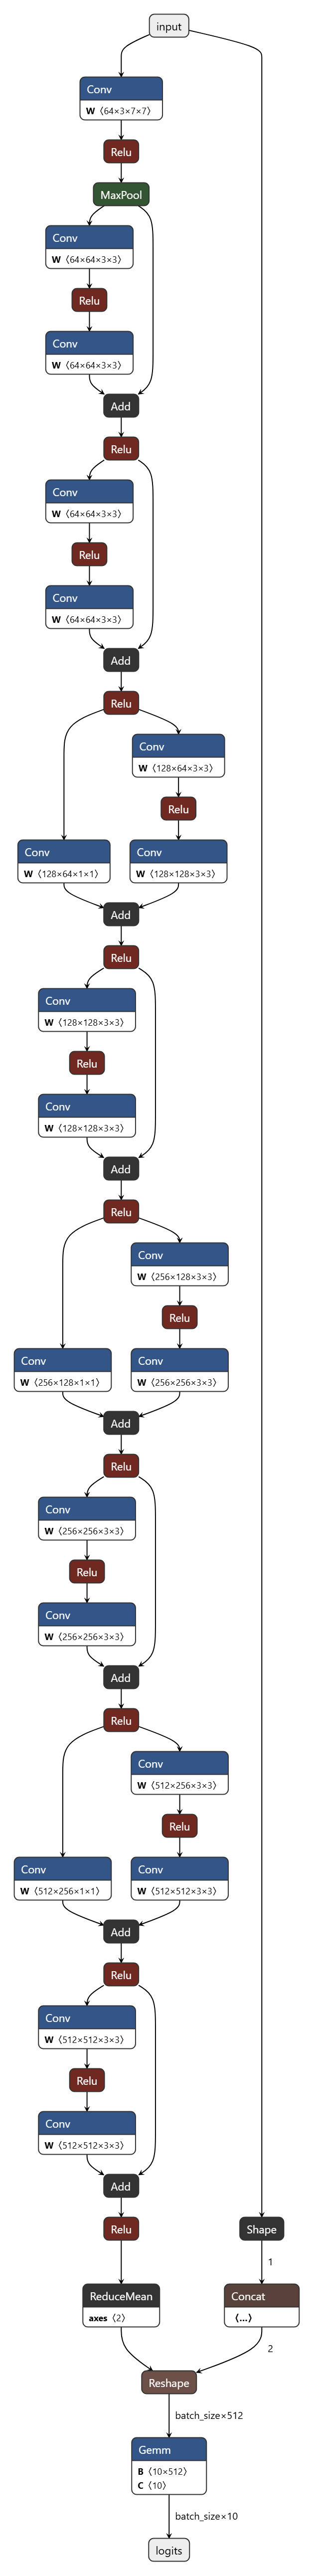